# Goal of this notebook is to find binary properties that work well for the full evolution

I.e., lab 1, give or take (find conservative case B mass transfer binary)
lab 3, sticking together through the end (have a binary that is on the edge of untstable mass transfer on the way back)

In [2]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.lines import Line2D

### Orbital evolution
Starting from the general eq for orbital evol
(pols lecture notes eq. 16.8)

$$
\frac{\dot{a}}{a} = -2\frac{\dot{M}_d}{M_d} \left[ 1 - \beta\frac{M_d}{M_a} - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{M_d}{M_d + M_a} \right]
$$

Rewrite in terms of $q = M_d/M_a$:

$$
\frac{\dot{a}}{a} = -2\frac{\dot{M}_d}{M_d} \left[ 1 - \beta q - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{q}{1+q} \right]
$$

Define the bracket as $f(q, \gamma)$ for compactness:

$$
f(q,\gamma) \equiv 1 - \beta q - (1-\beta)\left(\gamma + \tfrac{1}{2}\right)\frac{q}{1+q}
$$

So we can simplify

$$\frac{\dot{a}}{a} = -\frac{2\dot{M}_d}{M_d}\, f(q,\gamma) \tag{1}$$

***

Our goal is to eliminate $\dot{M}_d$ and just write the equation in terms of $da$ and $dq$ so we can integrate the orbital evolution assuming $beta$ is constant and without knowing $\dot{M}_d$ at every timestep

In order to do this we will need $\frac{\dot{q}}{q}$

The donor loses mass at rate $\dot{M}_d < 0$. The accretor gains a fraction $\beta$:
$$
\dot{M}_a = -\beta \dot{M}_d
$$

Now differentiate $q = M_d / M_a$:

$$
\dot{q} = \frac{\dot{M}_d}{M_a} - \frac{M_d}{M_a}\frac{\dot{M}_a}{M_a}
$$

Substitute $\dot{M}_a = -\beta \dot{M}_d$:

$$
\dot{q} = \frac{\dot{M}_d}{M_a} + \beta\frac{M_d}{M_a}\frac{\dot{M}_d}{M_a} = \frac{\dot{M}_d}{M_a}\left(1 + \beta q\right)
$$

From which we can get $\frac{\dot{q}}{q}$ by dividing both sides by $q = M_d/M_a$:

$$
 \frac{\dot{q}}{q} = \frac{\dot{M}_d}{M_d}\left(1 + \beta q\right) \tag{2}
$$

***

Divide equation (1) by equation (2):

$$
\frac{\dot{a}/a}{\dot{q}/q} = \frac{-2\dot{M}_d/M_d \cdot f(q,\gamma)}{\dot{M}_d/M_d \cdot (1 + \beta q)}
$$

The $\dot{M}_d/M_d$ cancels:

$$
\frac{\dot{a}/a}{\dot{q}/q} = \frac{-2\, f(q,\gamma)}{1 + \beta q} \tag{3}
$$

Also remember that 

$$
\frac{d\ln a}{a} = 1/a
$$

so we can use this to cancel out the dt 

$$
\frac{\dot{a}/a}{\dot{q}} = \frac{d \ln a}{dq} 
$$

and we end up with

$$
\frac{d\ln a}{d q} = \frac{-2\,f(q,\gamma)}{q(1 + \beta q)} \tag{4}
$$


$$
\boxed{\frac{d\ln a}{dq} = \frac{-2}{q(1+\beta q)}\left[1 - \beta q - (1-\beta)\left(\gamma+\tfrac{1}{2}\right)\frac{q}{1+q}\right]}
$$

This ODE depends only on $q$, $\beta$, and $\gamma$, **$\dot{M}_d$ dropped out entirely**.
Given an initial separation $a_0$ at $q = q_0$, you can integrate numerically to find $a(q)$ for any mass-transfer history, regardless of the Mdot.

### Gamma cases 

| Mode | $\gamma$ |
|---|---|
| Jeans (fast) | $\gamma = M_a/M_d = 1/q$ |
| Isotropic re-emission | $\gamma = M_d/M_a = q$ |
| Circumbinary ring | $\gamma = \dfrac{(M_d+M_a)^2}{M_d M_a}\sqrt{\dfrac{a_\mathrm{ring}}{a}} = \dfrac{(1+q)^2}{q}\sqrt{\dfrac{a_\mathrm{ring}}{a}}$ |

Note that for the ring case, $\gamma$ depends on $a$ itself, so it must be updated at each integration step (which the numerical code handles automatically).


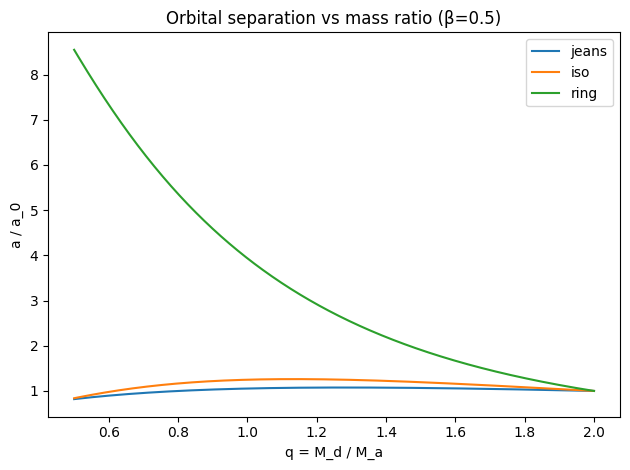

In [3]:
def dlna_dq(q, ln_a, beta, gamma_func, a_ring_over_a=None):
    """
    d(ln a)/dq as a function of q = M_d/M_a.

    Derived by dividing ȧ/a by q̇/q, so Ṁ_d cancels out.

    Parameters
    ----------
    q          : float - mass ratio M_d/M_a
    ln_a       : float - log of separation (state variable)
    beta       : float - accretion efficiency
    gamma_func : str   - one of 'jeans', 'iso', 'ring'
    a_ring_over_a : float - only needed for 'ring' mode
    """
    a = np.exp(ln_a[0])

    # Compute gamma
    if gamma_func == 'jeans':
        gamma = 1.0 / q          # gamma = M_a/M_d = 1/q
    elif gamma_func == 'iso':
        gamma = q                # gamma = M_d/M_a = q
    elif gamma_func == 'ring':
        gamma = ((1 + q)**2 / q) * np.sqrt(a_ring_over_a)
    else:
        raise ValueError(f"Unknown gamma_func: {gamma_func}")

    # d(ln a)/d(ln q): derived from ȧ/a divided by q̇/q
    # q̇/q = Ṁ_d/M_d - Ṁ_a/M_a = Ṁ_d/M_d * (1 + beta*q) / ... 
    # full result:
    numerator   = 2 * (1 - beta*q - (1 - beta)*(gamma + 0.5)*q/(1 + q))
    denominator = 1 + beta * q   # from dq/d(ln Md)

    dlna_dlnq = numerator / denominator

    # convert: d(ln a)/dq = d(ln a)/d(ln q) * (1/q)
    return [dlna_dlnq / q]


def integrate_separation(q_start, q_end, beta, gamma_func, a0=1.0,
                          a_ring_over_a=2.3, n_points=500):
    """
    Integrate orbital separation from q_start to q_end.

    Returns
    -------
    q_arr : array of mass ratios
    a_arr : array of separations (in units of a0)
    """
    ln_a0  = [np.log(a0)]
    q_span = (q_start, q_end)
    q_eval = np.linspace(q_start, q_end, n_points)

    sol = solve_ivp(
        fun=lambda q, y: dlna_dq(q, y, beta, gamma_func, a_ring_over_a),
        t_span=q_span,
        y0=ln_a0,
        t_eval=q_eval,
        method='RK45',
        rtol=1e-8, atol=1e-10
    )

    return sol.t, np.exp(sol.y[0])


# --- Example ---
# 45/23  P = 17.0  beta = 0.75
q_i, q_f = 2.0, 0.5   # donor starts more massive, ends less massive
beta      = 0.5

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for mode in ['jeans', 'iso', 'ring']:
    q_arr, a_arr = integrate_separation(q_i, q_f, beta=beta, gamma_func=mode)
    ax.plot(q_arr, a_arr, label=mode)

ax.set_xlabel('q = M_d / M_a')
ax.set_ylabel('a / a_0')
ax.legend()
ax.set_title(f'Orbital separation vs mass ratio (β={beta})')
plt.tight_layout()
plt.show()

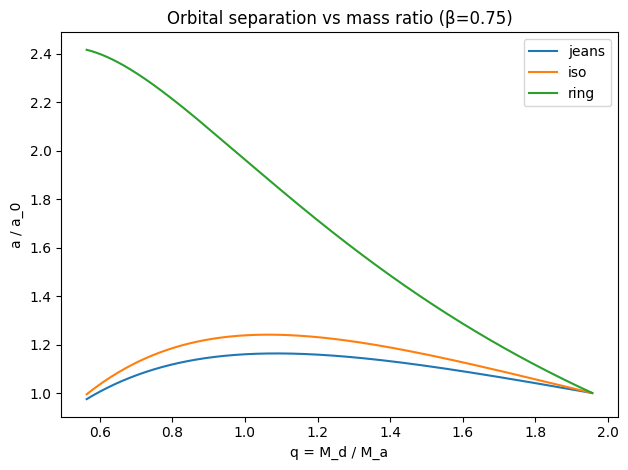

In [4]:
# --- Example ---
m1_i, m2_i = 45, 23
q_i = m1_i / m2_i
# qstart = 45/23 

# P start = 17.0  
beta = 0.75
# qfinal = 0.5*45/ (23 + 0.75*45*0.5)
q_f = (0.5*m1_i)/ (m2_i + beta *m1_i*0.5)

# q_i, q_f = 2.0, 0.5   # donor starts more massive, ends less massive

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for mode in ['jeans', 'iso', 'ring']:
    q_arr, a_arr = integrate_separation(q_i, q_f, beta=beta, gamma_func=mode)
    ax.plot(q_arr, a_arr, label=mode)

ax.set_xlabel('q = M_d / M_a')
ax.set_ylabel('a / a_0')
ax.legend()
ax.set_title(f'Orbital separation vs mass ratio (β={beta})')
plt.tight_layout()
plt.show()


 # Finding conservative case-B mass transfer anchors in the post-MT catalog

 ## Goal
 Identify observed massive post-MT binaries that serve as evidence for
 **conservative case-B mass transfer**, 
 then determine approximate pre-MT conditions for MESA
 (M1_ZAMS, M2_ZAMS, P_ZAMS, beta) that reproduce them 
 
 — with the requirement that the system is a BBH progenitor going through two stable MT phases.

 ## Strategy
 1. Load the catalog 
 2. Filter for WR+O binaries and massive Algols.
 4. Predict post-MT outcomes for a grid of (M1_i, M2_i, P_i, beta) using a
    semi-analytic treatment (He core mass ~ 0.4 M_ZAMS, integrate
    d ln a / dq numerically for non-conservative MT).
 5. Plot observed vs predicted in (M1, M2) and (M_tot, P) space.

In [5]:
catalog_dir = '/Users/liekevanson/Documents/Projects/post_mt_review/data/'
catalog_file = f'{catalog_dir}post_mt_systems.json'

## 1. Load the catalog into a flat DataFrame
Catalog entries store values as `[low_err, central, high_err]` lists;
`central()` pulls out the central value robustly.


In [6]:

def central(x):
    """Extract central value from [low_err, value, high_err] list or scalar."""
    if x is None:
        return np.nan
    if isinstance(x, list):
        if len(x) >= 2:
            return x[1] if x[1] is not None else np.nan
        return x[0] if x[0] is not None else np.nan
    return x


def load_catalog(path):
    with open(path) as f:
        data = json.load(f)
    rows = []
    for d in data:
        rows.append({
            'name':  d['System Name'],
            'class': d['system_class'],
            'M1':    central(d.get('M1')),
            'M2':    central(d.get('M2')),
            'P':     central(d.get('Period')),
            'e':     central(d.get('Eccentricity')),
            'obs1':  d.get('obs_type_1'),
            'obs2':  d.get('obs_type_2'),
            'evol1': d.get('evol_type_1'),
            'evol2': d.get('evol_type_2'),
        })
    return pd.DataFrame(rows)

df = load_catalog(catalog_file)
print(f"Total systems: {len(df)}")
print("\nSystem classes:")
print(df['class'].value_counts())


Total systems: 5447

System classes:
class
Astrometric WD + MS             3137
WUMa binary                      684
WD + MS                          446
Spectroscopic WD + MS            365
high-mass XRB                    162
Hot subdwarf binary              146
Algol                            126
Chemically Peculiar               82
Post-AGB binary                   77
EL CVn                            65
WR binary                         45
Contact binary                    27
Astrometric compact object        24
Blue straggler binary             22
Spectroscopic compact object      14
pulsar binary                      9
Intermediate-M stripped star       8
He giant                           4
Symbiotic XRB                      3
Self-lensing WD + MS               1
Name: count, dtype: int64



## 2. Extract WR+O systems
Use catalog-native notation throughout:
`M1` and `M2` are kept exactly as provided in the catalog.
For WR binaries in this catalog: `M1` is the O-star (accretor) and `M2` is the WR/He-star (donor).

In [7]:
wr = df[df['class'] == 'WR binary'].dropna(subset=['M1', 'M2', 'P']).copy()
wr['M_tot'] = wr['M1'] + wr['M2']
print(f"WR+O binaries with both masses measured: {len(wr)}")

WR+O binaries with both masses measured: 20


 ## 3. Apply cuts for BBH-progenitor relevance


In [8]:
# looking for high-mass (companion > 20) to still form BH
bbh_progen_mask = (wr['M_tot'] > 20) # & (wr['P'] < 50) 
wr_bbh = wr[bbh_progen_mask].sort_values('P')

print(f"WR+O systems with Mtot > 20: {len(wr_bbh)}")
print(wr_bbh[['name', 'M1', 'M2', 'M_tot', 'P', 'e', 'obs1', 'obs2']]
      .to_string(index=False))

# Also grab high-mass Algols for context (semi-detached, mid-MT systems)
algol = df[df['class'] == 'Algol'].copy()
algol = algol.dropna(subset=['M1', 'M2', 'P'])
algol_mask = (algol['M1'] + algol['M2'] > 20) #& (algol['P'] < 50)
algol_hm = algol[algol_mask].copy()
print(f"\nHigh-mass Algols: {len(algol_hm)}")
print(algol_hm[['name', 'M2', 'M1', 'P', 'e', 'obs1', 'obs2']].to_string(index=False))

# Let's include sdOBs
sdOB = df[df['class'] == 'Hot subdwarf binary'].copy()
sdOB = sdOB.dropna(subset=['M1', 'M2', 'P'])
sdOB_mask = (sdOB['M1'] + sdOB['M2'] > 10) #& (sdOB['P'] < 50)
sdOB_hm = sdOB[sdOB_mask].copy()
print(f"\nHigh-mass sdOBs: {len(sdOB_hm)}")
print(sdOB_hm[['name', 'M2', 'M1', 'P', 'e', 'obs1', 'obs2']].to_string(index=False))

WR+O systems with Mtot > 20: 19
     name    M1    M2  M_tot           P      e     obs1      obs2
   WR 155 24.50 27.60  52.10    1.641244 0.0100      WN6   O9II-Ib
   WR 151 20.40 28.90  49.30    2.126870 0.0000      WN4       O5V
BAT99 129 27.00 16.00  43.00    2.768700 0.0000     O4 V    WR-WN5
   WR 139 10.70 26.40  37.10    4.212500 0.0000      WN5   O6III-V
    WR 47 41.80 50.40  92.20    6.239300 0.0000      WN6       O5V
 SMC AB 6 41.00 18.00  59.00    6.538400 0.0000 O-O5.5 V    WR-WN3
    WR 42 14.00 23.00  37.00    7.886000 0.0000      WC7       O7V
    WR 21 19.00 37.00  56.00    8.254600 0.0400      WN5      O4-6
   WR 127 21.20 30.90  52.10    9.555000 0.0000      WN3     O9.5V
     WR 9  9.00 32.00  41.00   14.305000 0.0000      WC5        O7
 BAT99 19 40.00 22.00  62.00   17.994000 0.0200     O6 V    WR-WN4
    WR 30 16.00 34.00  50.00   18.820000    NaN      WC6      O6-8
 SMC AB 8 61.00 19.00  80.00   19.560000 0.1000   O-O4 V    WR-WO4
 SMC AB 7 44.00 23.00  67.00  

## 4. Predict post-MT outcomes for a (M1_i, M2_i, P_i, beta) grid

### We make the following assumptions:
- Donor is stripped to its He core: $M_\mathrm{He} \approx  f_{core} \,M_\mathrm{ZAMS}$
- Accretor gains $\beta \cdot \Delta M$ of the transferred material.
- Orbital response:
  - **Conservative (β=1):** $a_f/a_i = (M_{1,i} M_{2,i}/(M_{1,f} M_{2,f}))^2$
  - **Partially conservative:** integrate $d\ln a / dq$ with isotropic re-emission
    for the fraction $(1-\beta)$ lost from the accretor.
- Period: $P \propto a^{3/2} / \sqrt{M_\mathrm{tot}}$

In [9]:
def predict_post_mt(Md_i, Ma_i, P_i, beta, frac_core=0.5):
    """
    Predict the post case-B MT state.

    Parameters
    ----------
    Md_i, Ma_i : Msun  (donor, accretor)
    P_i        : days
    beta       : fraction of transferred mass accreted (1 = fully conservative)
    frac_core  : fraction of Md_ZAMS that remains as He-core after stripping

    Returns
    -------
    Md_f, Ma_f, P_f
    """
    # Final masses 
    Md_f = frac_core * Md_i
    dM   = Md_i - Md_f
    Ma_f = Ma_i + beta * dM

    q_i   = Md_i / Ma_i 
    q_f   = Md_f / Ma_f

    if beta == 1.0:
        a_ratio = (Md_i * Ma_i / (Md_f * Ma_f))**2
        # Change separation to period using Kepler
        P_ratio = a_ratio**1.5

    else:
        # Integrate d ln a / dq assuming isotropic re-emission for the lost fraction
        def dlna_dq(q, lna):
            gamma = q                                           # iso re-emission
            f = 1 - beta*q - (1-beta)*(gamma + 0.5)*q/(1+q)
            return [-2*f / (q*(1 + beta*q))]

        sol = solve_ivp(dlna_dq, (q_i, q_f), [0.0], rtol=1e-8)
        a_ratio = np.exp(sol.y[0, -1])

        # Change separation to period using Kepler
        Mtot_i = Md_i + Ma_i
        Mtot_f = Md_f + Ma_f
        P_ratio = (a_ratio**3 * Mtot_i / Mtot_f)**0.5

    return Md_f, Ma_f, P_i * P_ratio



### Generate a set of scenarios varying (M1_i, M2_i), P_i and beta

In [ ]:
scenarios = []
for M1_i, M2_i in [(30,15), (35, 28), (40, 30)]:
    # we are only looking for non-zero beta 
    for beta in [0.25, 0.5, 0.75, 1.0]:
        for P_i in [5, 10, 15, 20]:
            M1_f, M2_f, P_f = predict_post_mt(M1_i, M2_i, P_i, beta,frac_core=0.5)
            scenarios.append({
                'M1_i': M1_i, 'M2_i': M2_i, 'P_i': P_i, 'beta': beta,
                'M1_pred': M1_f, 'M2_pred': M2_f, 'P_pred': P_f,
                'M_tot_pred': M1_f + M2_f,
            })
scen = pd.DataFrame(scenarios)
print(scen.to_string(index=False))


 M1_i  M2_i  P_i  beta  M1_pred  M2_pred    P_pred  M_tot_pred
   30    15    5  0.25     15.0   18.750  4.886718      33.750
   30    15   10  0.25     15.0   18.750  9.773436      33.750
   30    15   15  0.25     15.0   18.750 14.660154      33.750
   30    15   20  0.25     15.0   18.750 19.546872      33.750
   30    15    5  0.50     15.0   22.500  5.056790      37.500
   30    15   10  0.50     15.0   22.500 10.113580      37.500
   30    15   15  0.50     15.0   22.500 15.170369      37.500
   30    15   20  0.50     15.0   22.500 20.227159      37.500
   30    15    5  0.75     15.0   26.250  5.075571      41.250
   30    15   10  0.75     15.0   26.250 10.151141      41.250
   30    15   15  0.75     15.0   26.250 15.226712      41.250
   30    15   20  0.75     15.0   26.250 20.302283      41.250
   30    15    5  1.00     15.0   30.000  5.000000      45.000
   30    15   10  1.00     15.0   30.000 10.000000      45.000
   30    15   15  1.00     15.0   30.000 15.000000     

## 5. Visualize: observed vs predicted in mass and period space


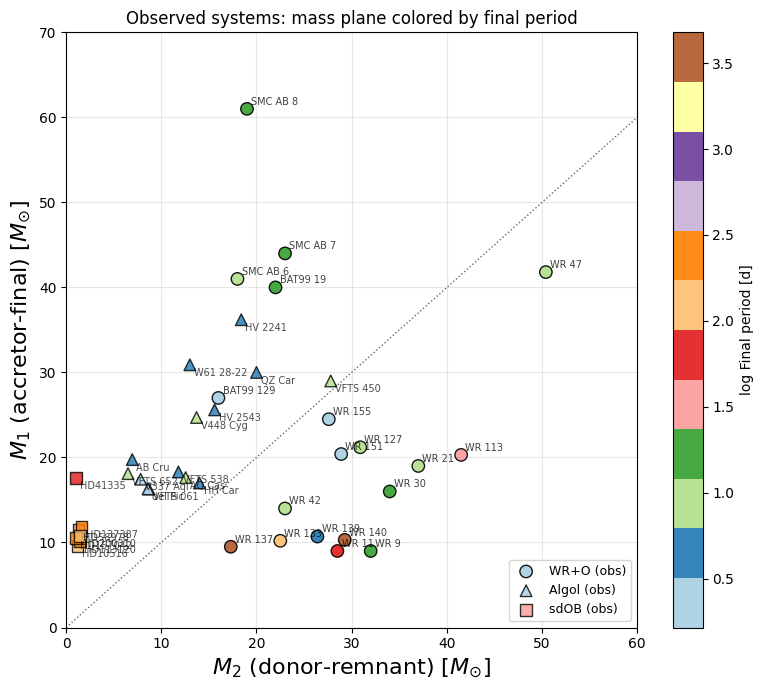

In [11]:
def plot_observed_vs_predicted(wr, algol_hm, savepath=None, cmap='Paired'):

    """Plot observed WR+O and Algol systems in one mass-plane panel.
    x-axis: donor remnant mass (catalog-based mapping)
    y-axis: final accretor mass (catalog-based mapping)
    color: final observed period
    """

    # For WR systems: M2 is donor (remnant), M1 is accretor.
    wr_plot = wr[['name', 'M1', 'M2', 'P']].dropna().copy()

    # For Algols, map lighter mass to x and heavier mass to y to match WR plane.
    algol_plot = algol_hm[['name', 'M1', 'M2', 'P']].dropna().copy()

    wr_x = wr_plot['M2'].values  # M2 = donor
    wr_y = wr_plot['M1'].values  # M1 = accretor
    algol_x = algol_plot['M2'].values  # M2 = donor
    algol_y = algol_plot['M1'].values  # M1 = accretor

    # Shared color scale for both classes
    all_periods = np.concatenate([wr_plot['P'].values, algol_plot['P'].values])
    vmin, vmax = np.nanmin(np.log10(all_periods)), np.nanmax(np.log10(all_periods))

    fig, ax = plt.subplots(figsize=(8, 7))

    # Plot WR + O stars
    sc_wr = ax.scatter(
        wr_x, wr_y,
        c=np.log10(wr_plot['P']), cmap=cmap, vmin=vmin, vmax=vmax,
        marker='o', s=80, edgecolor='k', alpha=0.9, label='WR+O (obs)', zorder=3
    )
    wr_names = wr_plot['name'].values
    for idx, name in enumerate(wr_names):
        ax.annotate(name, (wr_x[idx], wr_y[idx]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points', alpha=0.75)

    # Plot Algols
    ax.scatter(
        algol_x, algol_y,
        c=np.log10(algol_plot['P']), cmap=cmap, vmin=vmin, vmax=vmax,
        marker='^', s=70, edgecolor='k', alpha=0.8, label='Algol (obs)', zorder=3
    )
    algol_names = algol_plot['name'].values
    for idx, name in enumerate(algol_names):
        ax.annotate(name, (algol_x[idx], algol_y[idx]), fontsize=7,
                    xytext=(3, -8), textcoords='offset points', alpha=0.7)

    # Plot sdOBs
    ax.scatter(
        sdOB_hm['M2'], sdOB_hm['M1'],
        c=np.log10(sdOB_hm['P']), cmap=cmap, vmin=vmin, vmax=vmax,
        marker='s', s=70, edgecolor='k', alpha=0.8, label='sdOB (obs)', zorder=3
    )
    sdob_x = sdOB_hm['M2'].values
    sdob_y = sdOB_hm['M1'].values
    sdob_names = sdOB_hm['name'].values
    for idx, name in enumerate(sdob_names):
        ax.annotate(name, (sdob_x[idx], sdob_y[idx]), fontsize=7,
                    xytext=(3, -8), textcoords='offset points', alpha=0.7)

    # Reference line x = y.
    xx = np.linspace(0, 60, 200)
    ax.plot(xx, xx, ls=':', color='0.4', lw=1)

    ax.set_xlabel(r'$M_2$ (donor-remnant) [$M_{\odot}$]', fontsize=16)
    ax.set_ylabel(r'$M_1$ (accretor-final) [$M_{\odot}$]', fontsize=16)
    ax.set_title('Observed systems: mass plane colored by final period')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 70)
    ax.legend(loc='lower right', fontsize=9)

    cbar = fig.colorbar(sc_wr, ax=ax)
    cbar.set_label('log Final period [d]')

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=130, bbox_inches='tight')
    plt.show()
    return

plot_observed_vs_predicted(wr_bbh, algol_hm, savepath='case_B_targets.png')

In [18]:
### Best-match scan: find initial conditions per observed target

def chi2_match(M1_pred, M2_pred, P_pred, M1_obs, M2_obs, P_obs):
    """Simple chi square metric in log/fractional space."""
    return (((M1_pred - M1_obs) / M1_obs)**2
            + ((M2_pred - M2_obs) / M2_obs)**2
            + (np.log10(P_pred / P_obs))**2)


def find_best_match(md_obs, ma_obs, P_obs,
                    md_range=np.arange(10, 40, 1),
                    ma_range=np.arange(15, 60, 2),
                    P_range=np.arange(2, 30, 0.5),
                    beta_range=(0.25, 0.5, 0.75, 1.0),
                    fcore=0.5):
    """
    Find the best-matching initial conditions for a given observed target.
    md_range : range of initial donor masses to scan
    ma_range : range of initial accretor masses to scan
    P_range  : range of initial periods to scan
    beta_range: range of accretion efficiencies to consider
    """
    best = (np.inf, None)
    for ma_i in ma_range:
        for md_i in md_range:
        # The initial donor must be more massive than the accretor to have started MT first
            if md_i <= ma_i:
                continue
            for P_i in P_range:
                for beta in beta_range:
                    try:
                        md_f, ma_f, P_f = predict_post_mt(md_i, ma_i, P_i, beta, frac_core=fcore)
                    except Exception:
                        continue
                    chi = chi2_match(md_f, ma_f, P_f, md_obs, ma_obs, P_obs)
                    if chi < best[0]:
                        best = (chi, (md_i, ma_i, P_i, beta, md_f, ma_f, P_f))
    return best


def build_targets_from_names(selected_names, wr_df, algol_df, sdOB_df):
    """Build (name, M2_obs, M1_obs, P_obs) tuples from wr_bbh + algol_hm.

    For WR binaries: M2 is donor (lighter, WR/He-star) and M1 is accretor (heavier, O-star).
    For Algols, use (min(M1,M2), max(M1,M2)) to match the same physical plane (lighter, heavier).
    """
    wr_lookup = {
        row['name']: (row['M2'], row['M1'], row['P'])  # (donor, accretor, period)
        for _, row in wr_df[['name', 'M1', 'M2', 'P']].dropna().iterrows()
    }
    algol_lookup = {
        row['name']: (min(row['M1'], row['M2']), max(row['M1'], row['M2']), row['P'])
        for _, row in algol_df[['name', 'M1', 'M2', 'P']].dropna().iterrows()
    }
    sdOB_lookup = {
        row['name']: (min(row['M1'], row['M2']), max(row['M1'], row['M2']), row['P'])
        for _, row in sdOB_df[['name', 'M1', 'M2', 'P']].dropna().iterrows()
    }

    targets_local = []
    missing = []

    for name in selected_names:
        if name in wr_lookup:
            m1_obs, m2_obs, p = wr_lookup[name]
            targets_local.append((name, float(m1_obs), float(m2_obs), float(p)))
        elif name in algol_lookup:
            m1_obs, m2_obs, p = algol_lookup[name]
            targets_local.append((name, float(m1_obs), float(m2_obs), float(p)))
        elif name in sdOB_lookup:
            m1_obs, m2_obs, p = sdOB_lookup[name]
            targets_local.append((name, float(m1_obs), float(m2_obs), float(p)))
        else:
            missing.append(name)

    if missing:
        print('Names not found in wr_bbh or algol_hm:')
        for n in missing:
            print(f'  - {n}')

    return targets_local




In [ ]:
print('Available WR+O names (wr_bbh):')
print(sorted(wr_bbh['name'].dropna().unique().tolist()))
print('\nAvailable Algol names (algol_hm):')
print(sorted(algol_hm['name'].dropna().unique().tolist()))

# Pick names from wr_bbh and/or algol_hm here:
selected_names = [
    'HD10516',
    'BAT99 19',
    'SMC AB 7',
    'SMC AB 6',
    'WR 127',
    'BAT99 129',
    'V448 Cyg',
]

targets = build_targets_from_names(selected_names, wr_bbh, algol_hm, sdOB_hm)

print('\nTargets used for fitting:')
for t in targets:
    print(t)

print('\nBest-matching ZAMS conditions per target:')
print(f"{'Target':12s} | {'md_i':>4s} {'ma_i':>4s} {'P_i':>5s} {'beta':>4s} "
      f"-> {'md_f':>6s} {'ma_f':>6s} {'P_f':>7s}")
for name, md_obs, ma_obs, P_obs in targets:
    chi, res = find_best_match(md_obs, ma_obs, P_obs)
    md_i, ma_i, Pi, b, md_f, ma_f, Pf = res
    print(f"{name:12s} | {md_i:4.0f} {ma_i:4.0f} {Pi:5.1f} {b:4.2f} "
          f"-> {md_f:6.1f} {ma_f:6.1f} {Pf:7.2f} d  (obs: {md_obs}, {ma_obs}, {P_obs})")

In [ ]:
HD10516_target = build_targets_from_names(['HD10516'], wr_bbh, algol_hm, sdOB_hm)

for name, md_obs, ma_obs, P_obs in HD10516_target:
    print(name, md_obs, ma_obs, P_obs)
    chi, res = find_best_match(md_obs, ma_obs, P_obs,
                    md_range=np.arange(1.2, 40, 1),
                    ma_range=np.arange(0.1, 9.6, 0.1),
                    P_range= 10**(np.linspace(0.3, 3, 50)),# np.arange(2, 1000, 10),
                    beta_range=(0.25, 0.5, 0.75, 1.0),
                    fcore=0.2
                    )
print(f"{'Target':12s} | {'md_i':>4s} {'ma_i':>4s} {'P_i':>5s} {'beta':>4s} "
      f"-> {'md_f':>6s} {'ma_f':>6s} {'P_f':>7s}")
md_i, ma_i, Pi, b, md_f, ma_f, Pf = res
print(f"{name:12s} | {md_i:4.0f} {ma_i:4.0f} {Pi:5.1f} {b:4.2f} "
        f"-> {md_f:6.1f} {ma_f:6.1f} {Pf:7.2f} d  (obs: {md_obs}, {ma_obs}, {P_obs})")

HD10516 1.2 9.6 126.6982


Target       | md_i ma_i   P_i beta ->   md_f   ma_f     P_f
HD10516      |    3    3  54.0 1.00 ->    1.6    4.7  124.03 d  (obs: 1.2, 9.6, 126.6982)


In [26]:
HD10516_target = build_targets_from_names(['HD10516'], wr_bbh, algol_hm, sdOB_hm)

for name, md_obs, ma_obs, P_obs in HD10516_target:
    print(name, md_obs, ma_obs, P_obs)
    chi, res = find_best_match(md_obs, ma_obs, P_obs,
                    md_range=np.arange(1.2, 10, 1),
                    ma_range=np.arange(1., 9.6, 0.5),
                    P_range= 10**(np.linspace(0.3, 2, 30)),# np.arange(2, 1000, 10),
                    beta_range=(0.25, 0.5, 0.75, 1.0),
                    fcore=0.15
                    )

print(f"{'Target':12s} | {'md_i':>4s} {'ma_i':>4s} {'P_i':>5s} {'beta':>4s} "
      f"-> {'md_f':>6s} {'ma_f':>6s} {'P_f':>7s}")
md_i, ma_i, Pi, b, md_f, ma_f, Pf = res
print(f"{name:12s} | {md_i:4.0f} {ma_i:4.0f} {Pi:5.1f} {b:4.2f} "
        f"-> {md_f:6.1f} {ma_f:6.1f} {Pf:7.2f} d  (obs: {md_obs}, {ma_obs}, {P_obs})")

HD10516 1.2 9.6 126.6982
Target       | md_i ma_i   P_i beta ->   md_f   ma_f     P_f
HD10516      |    8    2  22.7 1.00 ->    1.2    9.5  123.50 d  (obs: 1.2, 9.6, 126.6982)
